Title: ERA5_SMARD_Comparison_2024.ipynb

Purpose: Compare output from SEM (with ERA5 climate data) with SMARD data (Data from German TSOs) to validate the model and calculate linear correction coefficients

Author: Onno Nennecke on 14.10.2025 Modified: 14.10.2025

Input data: 

- ERA5 Residual Load Timeseries
    - This file lies here: /climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_timeseries_wwd.nc
    - This file lies here: /climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_timeseries_week.nc
- SMARD Production and demand Timeseries
    - This file lies here: /home/onennecke/SMARD_data/Realisierte_Erzeugung_201501010000_202505010000_Tag.csv
    - This file lies here: /home/onennecke/SMARD_data/Realisierter_Stromverbrauch_201501010000_202505010000_Tag.csv

Output data:

- regression_coefficients
    - This file lies here: /climca/people/onennecke/model_output/lr_correction/regression_coefficients.csv
- Evaluation Scatter Plots: Mod_eval_scatterplt, Mod_eval_scatterplt_winter, Mod_eval_scatterplt_high_rl
    - These files lie here: /home/onennecke/Code/Figures/
- Evaluation Demand Plots: demand_correlation_combined_draft, demand_correlation_weekly_draft, demand_correlation_wwd_draft, demand_correlation_wwd_draft_RM, demand_time_series_RM_draft, demand_time_series_draft, demand_rolling_mean_draft, demand_rolling_mean_combined_draft, demand_per_year_scatter_draft, demand_fit_germany_draft
    - These files lie here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
import seaborn as sns
from scipy.stats import pearsonr
# import scipy.ndimage as ndimage
# import os
# import glob

# Importing custom functions
import Functions.demand as demand

In [2]:
ERA5_dataset_wwd = xr.open_dataset('/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_timeseries_wwd.nc')
ERA5_dataset = xr.open_dataset('/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_hist_timeseries.nc')


# # ERA5_dataset = xr.open_dataset('/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_timeseries_wwd.nc')
# ERA5_dataset = xr.open_dataset('/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/ERA5_timeseries_wwd.nc')

# # ERA5_dataset_week = xr.open_dataset('/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_timeseries_week.nc')
# ERA5_dataset_week = xr.open_dataset('/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/ERA5_timeseries_week.nc')

ERA5_dataset.load()

# Cut to 2024
ERA5_dataset = ERA5_dataset.sel(time=slice('2024-01-01', '2024-12-31'))
ERA5_dataset_wwd = ERA5_dataset_wwd.sel(time=slice('2024-01-01', '2024-12-31'))
ERA5_dataset

<xarray.Dataset> Size: 32kB
Dimensions:        (time: 365)
Coordinates:
  * time           (time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-31
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U9 36B 'ERA5_week'
    run            <U4 16B 'hist'
    ESM_run        <U14 56B 'ERA5_hist_week'
    country        float64 8B 9.0
    period         <U4 16B 'week'
Data variables:
    temp           (time) float64 3kB 5.999 6.811 8.735 ... 0.7396 0.4142
    demand         (time) float64 3kB 1.445e+03 1.435e+03 ... 1.515e+03
    sfcWind        (time) float32 1kB 8.587 9.333 11.08 ... 6.159 8.049 8.775
    rsds           (time) float32 1kB 27.92 8.813 20.89 ... 28.84 26.3 31.92
    tas            (time) float32 1kB 5.512 5.841 7.682 ... 0.2238 1.512 1.194
    tasmax         (time) float32 1kB 6.752 8.106 9.182 ... 2.446 2.709 3.361
    wind_off_prod  (time) float64 3kB 142.8 126.4 190.0 ... 179.2 221.1 221.1
    wind_on_prod   (time) float64 3kB 497.7 562.7 1.062e+03 ... 592.8 602.7
    solar_prod     (time) float64 3kB 73.77 19.14 57.68 ... 78.49 72.3 91.06
    total_prod     (time) float64 3kB 714.2 708.2 1.31e+03 ... 474.3 886.3 914.8
    Netto          (time) float64 3kB -731.0 -726.6 -100.1 ... -624.5 -600.0
    Residual_load  (time) float64 3kB 731.0 726.6 100.1 ... 624.5 600.0

### Load SMARD data

In [3]:
SMARD_data_prod = pd.read_csv('/home/onennecke/SMARD_data/Realisierte_Erzeugung_201501010000_202505010000_Tag.csv', sep=';', decimal=',', thousands='.')
SMARD_data_demand = pd.read_csv('/home/onennecke/SMARD_data/Realisierter_Stromverbrauch_201501010000_202505010000_Tag.csv', sep=';', decimal=',', thousands='.')

In [4]:

date = pd.to_datetime(SMARD_data_prod['Datum von'].astype(str).str.zfill(8), format='%d%m%Y')
demand_sm = SMARD_data_demand['Netzlast [MWh] Berechnete Auflösungen']
wind_off_prod = SMARD_data_prod['Wind Offshore [MWh] Berechnete Auflösungen']
wind_on_prod = SMARD_data_prod['Wind Onshore [MWh] Berechnete Auflösungen']
solar_prod = SMARD_data_prod['Photovoltaik [MWh] Berechnete Auflösungen']
total_prod = wind_off_prod + wind_on_prod + solar_prod
residual_load = demand_sm - total_prod

df = pd.DataFrame({
    'date': date,
    'demand_SMARD': demand_sm / 1000,  # Convert to GWh
    'wind_offshore_SMARD': wind_off_prod / 1000,  # Convert to GWh
    'wind_onshore_SMARD': wind_on_prod / 1000,  # Convert to GWh
    'solar_SMARD': solar_prod / 1000,  # Convert to GWh
    'total_production_SMARD': total_prod / 1000,  # Convert to GWh
    'residual_load_SMARD': residual_load / 1000,  # Convert to GWh
})


In [5]:
# Cut data to the same time period as ERA5 data (2024)
df = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-12-31')]
# Remove leap days
df = df[~((df['date'].dt.month == 2) & (df['date'].dt.day == 29))]
df

,date,demand_SMARD,wind_offshore_SMARD,wind_onshore_SMARD,solar_SMARD,total_production_SMARD,residual_load_SMARD
3287,2024-01-01,1021.08000,101.28375,675.50775,38.01800,814.80950,206.27050
3288,2024-01-02,1271.12725,114.71750,692.63100,10.70225,818.05075,453.07650
3289,2024-01-03,1354.05050,96.27300,903.23100,32.26475,1031.76875,322.28175
3290,2024-01-04,1381.90350,65.05600,532.89325,26.35675,624.30600,757.59750
3291,2024-01-05,1366.75825,131.69200,434.75150,25.62100,592.06450,774.69375
...,...,...,...,...,...,...,...
3648,2024-12-27,1155.15125,2.94125,46.42200,61.20575,110.56900,1044.58225
3649,2024-12-28,1150.65975,22.34775,31.44225,61.08850,114.87850,1035.78125
3650,2024-12-29,1179.16200,97.29825,257.39450,39.71900,394.41175,784.75025
3651,2024-12-30,1278.28500,61.18675,534.34725,22.92750,618.46150,659.82350


### Combine both datasets

In [6]:
df['sfcWind'] = ERA5_dataset['sfcWind'].values
df['rsds'] = ERA5_dataset['rsds'].values
df['tas'] = ERA5_dataset['tas'].values
df['tasmax'] = ERA5_dataset['tasmax'].values
df['temp_ERA5'] = ERA5_dataset['temp'].values
df['demand_ERA5_wwd'] = ERA5_dataset_wwd['demand'].values
df['demand_ERA5'] = ERA5_dataset['demand'].values
df['RL_ERA5'] = ERA5_dataset['Residual_load']

df['wind_offshore_ERA5'] = ERA5_dataset['wind_off_prod'].values
df['wind_onshore_ERA5'] = ERA5_dataset['wind_on_prod'].values
df['solar_ERA5'] = ERA5_dataset['solar_prod'].values
df['total_production_ERA5'] = df['wind_offshore_ERA5'] + df['wind_onshore_ERA5'] + df['solar_ERA5']
# df['total_production_ERA5_check'] = ERA5_dataset['total_prod'].values

In [7]:
# Add weekday or weekend
df['weekday'] = df['date'].dt.dayofweek + 1
df['period'] = np.where(df['weekday'] <= 5, 'Weekday', 'Weekend')

In [8]:
# Define national fixed-date holidays (month, day)
fixed_holidays = [
    (1, 1),   # New Year's Day
    (5, 1),   # Labor Day
    (10, 3),  # German Unity Day
]

# Start by setting all to 'other'
df['special'] = df['period'].copy()

# Summer
df.loc[(df['date'].dt.month == 7) & (df['date'].dt.day >= 15), 'special'] = 'summer'
df.loc[(df['date'].dt.month == 8) & (df['date'].dt.day <= 15), 'special'] = 'summer'


# Christmas period (Dec 20–31)
df.loc[(df['date'].dt.month == 12) & (df['date'].dt.day >= 23), 'special'] = 'christmas'

# Fixed-date holidays
is_fixed_holiday = df['date'].dt.month.astype(str).str.zfill(2) + '-' + df['date'].dt.day.astype(str).str.zfill(2)
fixed_strs = [f"{m:02d}-{d:02d}" for m, d in fixed_holidays]
df.loc[is_fixed_holiday.isin(fixed_strs), 'special'] = 'holiday'

### linear regression-based bias correction

In [9]:
# coeff_df.to_csv('/climca/people/onennecke/model_output/lr_correction/regression_coefficients.csv', index=False)

# Read coefficients
coeff_df = pd.read_csv('/climca/people/onennecke/model_output/lr_correction/regression_coefficients.csv')
coeff_df

,variable,a,b
0,wind_onshore,1.124425,-94.881416
1,wind_offshore,1.413661,3.619486
2,solar,1.819809,55.414392
3,total_production,1.106414,74.877238


In [10]:
# List to store coefficient records
coeff_records = []

variables = [
    ('wind_onshore_SMARD', 'wind_onshore_ERA5'),
    ('wind_offshore_SMARD', 'wind_offshore_ERA5'),
    ('solar_SMARD', 'solar_ERA5'),
    ('total_production_SMARD', 'total_production_ERA5')
]
for smard_var, era5_var in variables:
    # smard = df[smard_var].values
    era5 = df[era5_var].values

    a = coeff_df.loc[coeff_df['variable'] == era5_var[:-5], 'a'].values[0]    
    b = coeff_df.loc[coeff_df['variable'] == era5_var[:-5], 'b'].values[0]

    # model = LinearRegression()
    # model.fit(smard.reshape(-1, 1), era5)

    # a = model.coef_[0]
    # b = model.intercept_
    
    # print(f"Regression coefficients for {era5_var}: a = {a}, b = {b}")
    
    # coeff_records.append({
    #     "variable": era5_var[:-5],
    #     "a": a,
    #     "b": b
    # })

    # Apply correction (inverse of the regression model to align with 1:1 line)
    era5_corrected = (era5 - b) / a
    
    df[era5_var + '_corrected'] = era5_corrected
    
df['tot_prod_other'] = df['wind_onshore_ERA5_corrected'] + df['wind_offshore_ERA5_corrected'] + df['solar_ERA5_corrected']
df['RL_corrected_old'] = df['demand_ERA5'] - df['total_production_ERA5_corrected']

In [11]:
df['tot_prod_s_off_corrected'] = df['wind_onshore_ERA5'] + df['wind_offshore_ERA5_corrected'] + df['solar_ERA5_corrected']
df['tot_prod_s_corrected'] = df['wind_onshore_ERA5'] + df['wind_offshore_ERA5'] + df['solar_ERA5_corrected']

In [12]:
df['RL_corrected'] = df['demand_ERA5'] - df['tot_prod_s_corrected']

In [13]:
# coeff_records

# # Convert to DataFrame and save as CSV
# coeff_df = pd.DataFrame(coeff_records)

# coeff_df.to_csv('/climca/people/onennecke/model_output/lr_correction/regression_coefficients.csv', index=False)

In [14]:
coeff_df

,variable,a,b
0,wind_onshore,1.124425,-94.881416
1,wind_offshore,1.413661,3.619486
2,solar,1.819809,55.414392
3,total_production,1.106414,74.877238


## Make plots to compare the datasets

### Production

#### Plot for thesis

In [15]:
rows = [
    "wind_onshore",
    'wind_onshore_cor',
    "wind_offshore",
    "wind_offshore_cor",
    "solar",
    "solar_cor",
    "total_production",
    "total_production_cor"
]
cols = ["whole_year", "winter", 'perc']

# Create empty DataFrame (filled with NaN)
metrics = pd.DataFrame(index=rows, columns=cols)

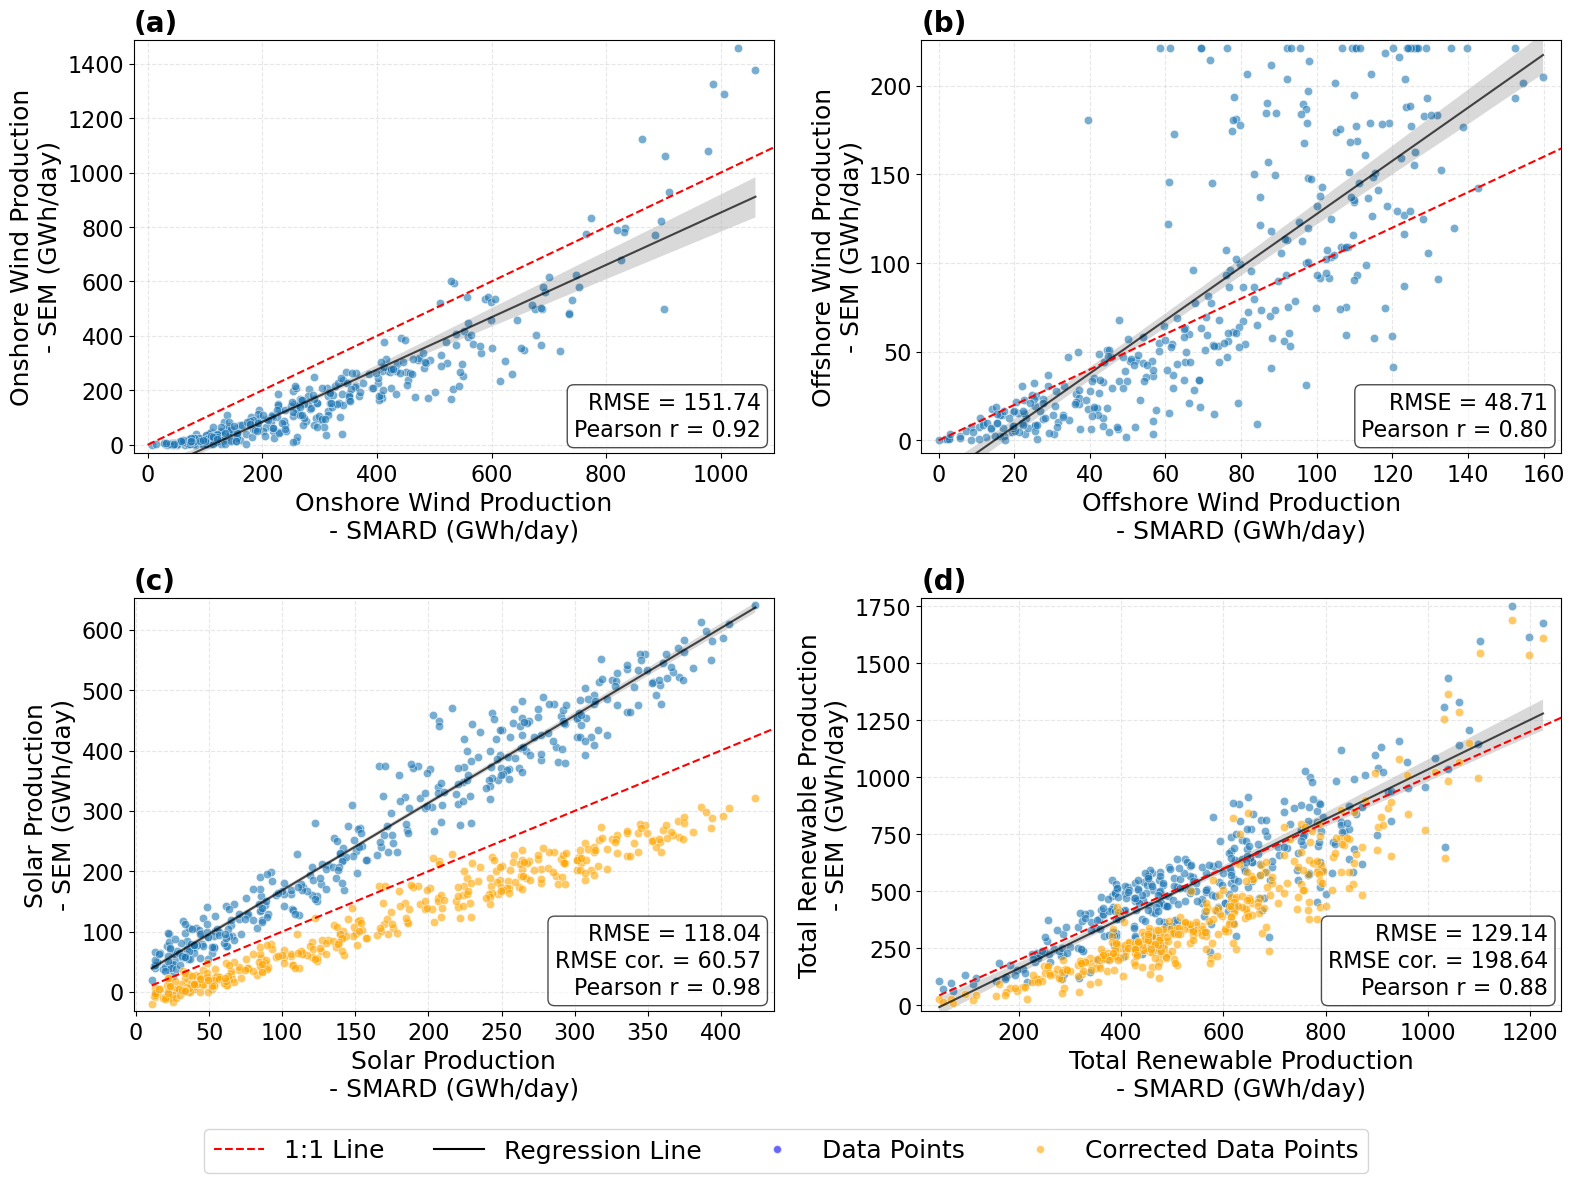

In [16]:
# --- Make all text bigger (global defaults) ---
mpl.rcParams.update({
    'font.size': 14+2,             # base font size (affects legends+2, labels, etc. unless overridden)
    'axes.titlesize': 18+2,        # axes title
    'axes.labelsize': 16+2,        # x/y labels
    'xtick.labelsize': 14+2,       # x tick labels
    'ytick.labelsize': 14+2,       # y tick labels
    'legend.fontsize': 16+2,       # legend text
    'figure.titlesize': 20+2,      # figure title (if used)
})

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plot_specs = [
    ('wind_onshore_SMARD', 'wind_onshore_ERA5', 'wind_onshore_ERA5_corrected', 'Onshore Wind Production'),
    ('wind_offshore_SMARD', 'wind_offshore_ERA5', 'wind_offshore_ERA5_corrected', 'Offshore Wind Production'),
    ('solar_SMARD', 'solar_ERA5', 'solar_ERA5_corrected', 'Solar Production'),
    ('total_production_SMARD', 'total_production_ERA5', 'tot_prod_s_corrected', 'Total Renewable Production')
]

subplot_labels = ['(a)', '(b)', '(c)', '(d)']

for idx, (ax, (col_smard, col_era5, col_era5_corrected, title)) in enumerate(zip(axs.flat, plot_specs)):
    top = col_smard[0:-6]
    top_cor = col_smard[0:-6] + '_cor'

    sns.scatterplot(x=col_smard, y=col_era5, data=df, alpha=0.6, ax=ax)
    
    # Regression line
    sns.regplot(x=col_smard, y=col_era5, data=df, scatter=False, color='black',
                line_kws={'linewidth': 1.5, 'alpha': 0.7}, ax=ax)
    
    # 1:1 line
    min_val = min(df[col_smard].min(), df[col_era5].min())
    max_val = max(df[col_smard].max(), df[col_era5].max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

    # Adjust axes
    xrange = df[col_smard].max() - df[col_smard].min()
    min_ERA5 = min(df[col_era5].min(), df[col_era5_corrected].min())
    max_ERA5 = max(df[col_era5].max(), df[col_era5_corrected].max())
    ax.set_xlim(df[col_smard].min() - xrange * 0.03, df[col_smard].max() + xrange * 0.03)
    ax.set_ylim(min_ERA5 - xrange * 0.03, max_ERA5 + xrange * 0.03)

    # Metrics
    r, _ = pearsonr(df[col_smard], df[col_era5])
    rmse = np.sqrt(np.mean((df[col_smard] - df[col_era5])**2))
    metrics.loc[top, 'whole_year'] = rmse
    rmse_corrected = np.sqrt(np.mean((df[col_smard] - df[col_era5_corrected])**2))
    metrics.loc[top_cor, 'whole_year'] = rmse_corrected

    # Corrected points
    if col_era5_corrected == 'solar_ERA5_corrected':
        sns.scatterplot(x=col_smard, y=col_era5_corrected, data=df, alpha=0.6, ax=ax, color='orange')

    if col_era5_corrected == 'tot_prod_s_corrected':
        sns.scatterplot(x=col_smard, y='tot_prod_s_corrected', data=df, alpha=0.6, ax=ax, color='orange')

    # Plot labels, titles (made larger)
    ax.set_xlabel(f'{title}\n- SMARD (GWh/day)')
    ax.set_ylabel(f'{title}\n- SEM (GWh/day)')
    ax.set_title(subplot_labels[idx], loc='left', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)

    if col_era5_corrected == 'solar_ERA5_corrected' or col_era5_corrected == 'tot_prod_s_corrected':
        # Add numeric-only legend info
        textstr = '\n'.join((
            f'RMSE = {rmse:.2f}',
            f'RMSE cor. = {rmse_corrected:.2f}',
            f'Pearson r = {r:.2f}'
        ))
    else:
        # Add numeric-only legend info
        textstr = '\n'.join((
            f'RMSE = {rmse:.2f}',
            f'Pearson r = {r:.2f}'
        ))
    
    ax.text(0.98, 0.03, textstr, transform=ax.transAxes,
            va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Create a common legend
legend_elements = [
    Line2D([0], [0], linestyle='--', color='red', label='1:1 Line'),
    Line2D([0], [0], linestyle='-', color='black', label='Regression Line'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Data Points', alpha=0.6),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', label='Corrected Data Points', alpha=0.6),
]

# Place common legend below all subplots (fontsize increased slightly)
fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=True, bbox_to_anchor=(0.5, 0))

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for legend

# Save the figure
plt.savefig('/home/onennecke/Code/Figures/Mod_eval_scatterplt_2024.png', dpi=300, bbox_inches='tight')
plt.show()
